In [1]:
# Bayesian Linear Regression

In [2]:
!pip install bambi

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 109.6/109.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 218.9/218.9 kB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.4/259.4 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 62.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.6/164.6 kB 12.1 MB/s eta 0:00:00


In [3]:
import pandas as pd
import numpy as np
import bambi as bmb

In [4]:
# load the ugtests data from current working directory
import pandas as pd

url = "https://raw.githubusercontent.com/keithmcnulty/peopleanalytics-regression-book/master/data/ugtests.csv"
ugtests = pd.read_csv(url)

# take a random sample of 100 rows
np.random.seed(123)
ugtests_bayes = ugtests.sample(n=100, random_state=123).copy()

# optional check
ugtests_bayes.head()

,Yr1,Yr2,Yr3,Final
877,31,122,113,170
764,14,59,159,174
788,32,117,108,191
727,50,116,131,183
898,58,115,112,147


In [5]:
# MCMC methods
# fit an uninformed Bayesian linear regression model
uninf_model = bmb.Model(
    formula="Final ~ Yr1 + Yr2 + Yr3",
    data=ugtests_bayes,
    family="gaussian"
)

uninf_results = uninf_model.fit(
    draws=10000,
    chains=4,
    random_seed=123
)

Output()

In [6]:
uninf_model

       Formula: Final ~ Yr1 + Yr2 + Yr3
        Family: gaussian
          Link: mu = identity
  Observations: 100
        Priors: 
    target = mu
        Common-level effects
            Intercept ~ Normal(mu: 154.63, sigma: 626.7374)
            Yr1 ~ Normal(mu: 0.0, sigma: 6.9113)
            Yr2 ~ Normal(mu: 0.0, sigma: 3.6767)
            Yr3 ~ Normal(mu: 0.0, sigma: 3.3494)
        
        Auxiliary parameters
            sigma ~ HalfStudentT(nu: 4.0, sigma: 44.2951)
------
* To see a plot of the priors call the .plot_priors() method.
* To see a summary or plot of the posterior pass the object returned by .fit() to az.summary() or az.plot_trace()

In [7]:
import arviz as az
az.summary(uninf_results)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,23.392,16.441,-8.467,53.394,0.070,0.079,55483.0,34040.0,1.0
Yr1,0.071,0.185,-0.271,0.426,0.001,0.001,48824.0,32069.0,1.0
Yr2,0.286,0.101,0.095,0.477,0.000,0.000,50345.0,33096.0,1.0
Yr3,0.934,0.092,0.766,1.112,0.000,0.000,47786.0,33332.0,1.0
sigma,29.481,2.152,25.537,33.519,0.010,0.011,52059.0,32978.0,1.0


In [8]:
import numpy as np

# extract posterior draws for the Yr3 coefficient
yr3_samples = uninf_results.posterior["Yr3"].values.flatten()

# basic checks
print("number of samples:", len(yr3_samples))
print("first 10 samples:", yr3_samples[:10])
print("posterior mean:", np.mean(yr3_samples))
print("94% interval:", np.quantile(yr3_samples, [0.03, 0.97]))

number of samples: 40000
first 10 samples: [0.9279782  0.86098359 0.98071492 0.82449084 1.07332859 0.95103432
 0.95453234 0.9195686  1.06389663 0.80444467]
posterior mean: 0.9338782596846439
94% interval: [0.76174032 1.10799277]


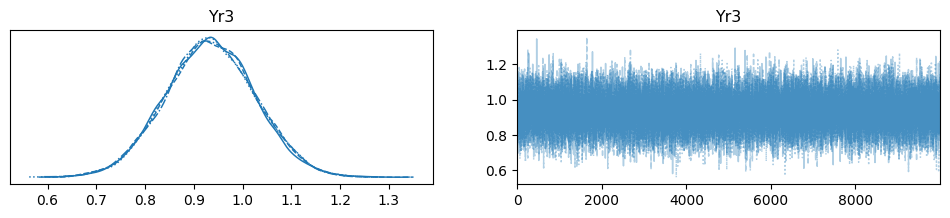

In [9]:
import arviz as az
import matplotlib.pyplot as plt

# trace plot for Yr3
az.plot_trace(uninf_results, var_names=["Yr3"])
plt.show()

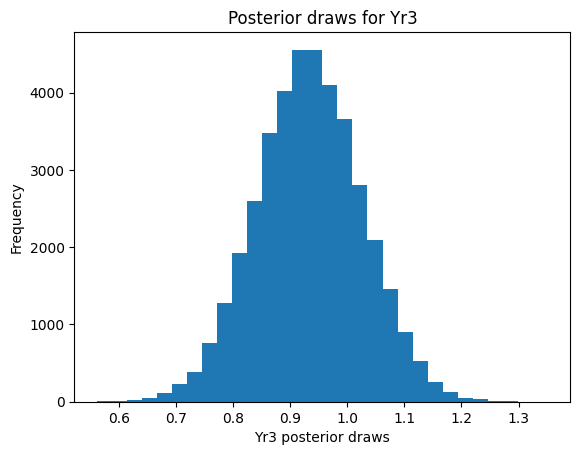

In [10]:
plt.hist(yr3_samples, bins=30)
plt.xlabel("Yr3 posterior draws")
plt.ylabel("Frequency")
plt.title("Posterior draws for Yr3")
plt.show()

In [11]:

priors = {
    "Yr1": bmb.Prior("Normal", mu=0, sigma=0.05)
}

inf_model = bmb.Model(
    formula="Final ~ Yr1 + Yr2 + Yr3",
    data=ugtests_bayes,
    family="gaussian",
    priors=priors
)

inf_results = inf_model.fit(
    draws=10000,
    chains=4,
    random_seed=123
)

Output()

In [12]:
# previous results
az.summary(uninf_results)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,23.392,16.441,-8.467,53.394,0.070,0.079,55483.0,34040.0,1.0
Yr1,0.071,0.185,-0.271,0.426,0.001,0.001,48824.0,32069.0,1.0
Yr2,0.286,0.101,0.095,0.477,0.000,0.000,50345.0,33096.0,1.0
Yr3,0.934,0.092,0.766,1.112,0.000,0.000,47786.0,33332.0,1.0
sigma,29.481,2.152,25.537,33.519,0.010,0.011,52059.0,32978.0,1.0


In [13]:
# new results
az.summary(inf_results)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
Intercept,27.284,12.608,2.966,50.391,0.046,0.063,73861.0,33279.0,1.0
Yr1,0.005,0.048,-0.087,0.093,0.000,0.000,58497.0,31408.0,1.0
Yr2,0.285,0.100,0.098,0.473,0.000,0.000,55041.0,33487.0,1.0
Yr3,0.931,0.092,0.759,1.102,0.000,0.000,54598.0,34115.0,1.0
sigma,29.364,2.135,25.465,33.396,0.010,0.011,50873.0,32319.0,1.0


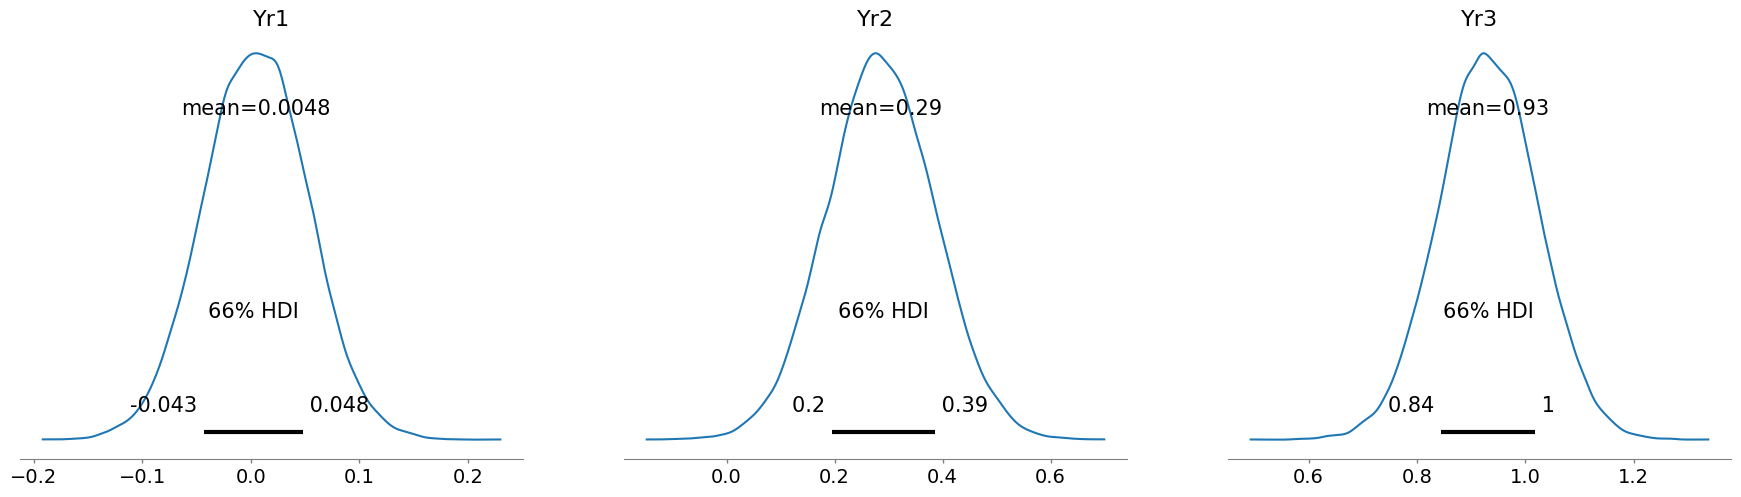

In [14]:
az.plot_posterior(
    inf_results,
    var_names=["Yr1", "Yr2", "Yr3"],
    hdi_prob=0.66
)

plt.show()

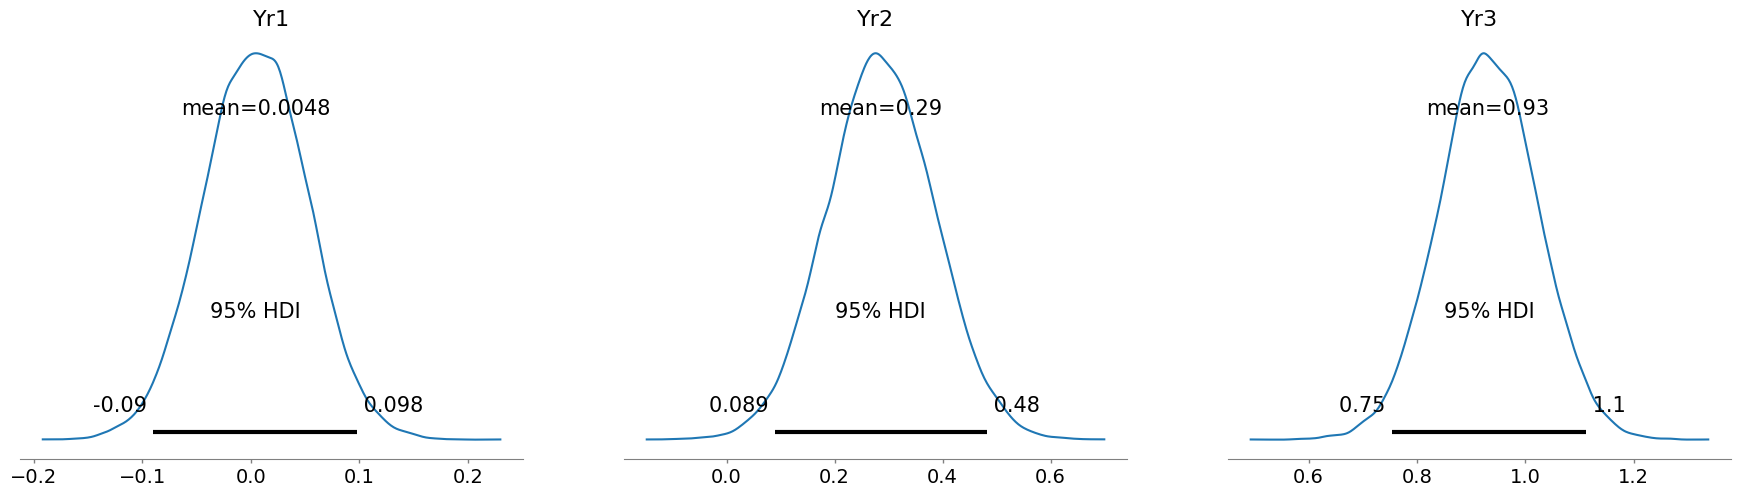

In [15]:
az.plot_posterior(
    inf_results,
    var_names=["Yr1", "Yr2", "Yr3"],
    hdi_prob=0.95
)

plt.show()

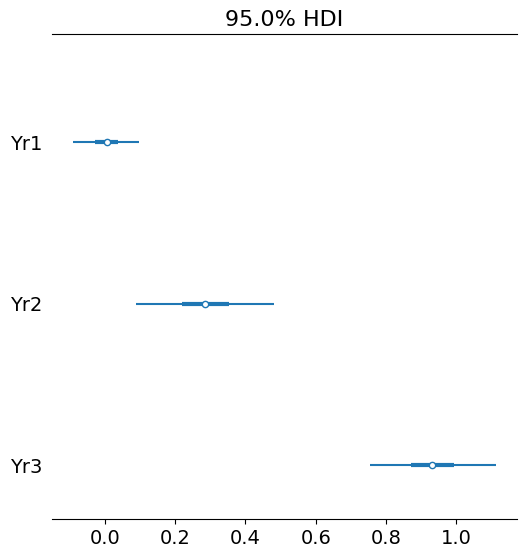

In [16]:
az.plot_forest(
    inf_results,
    var_names=["Yr1", "Yr2", "Yr3"],
    combined=True,
    hdi_prob=0.95
)

plt.show()

In [17]:
# new student
new_student = pd.DataFrame({
    "Yr1": [43],
    "Yr2": [111],
    "Yr3": [143]
})

# add posterior predictive draws to inf_results in place
inf_model.predict(
    inf_results,
    data=new_student,
    kind="response",
    inplace=True
)

# extract draws
pred_values = inf_results.posterior_predictive["Final"].values.flatten()

# summarize
print("number of samples:", len(pred_values))
print("mean prediction:", np.mean(pred_values))
print("95% interval:", np.quantile(pred_values, [0.025, 0.975]))

number of samples: 40000
mean prediction: 192.1056033702774
95% interval: [133.63698073 250.82595994]


In [18]:
print(list(inf_results.posterior_predictive.data_vars))

['Final']


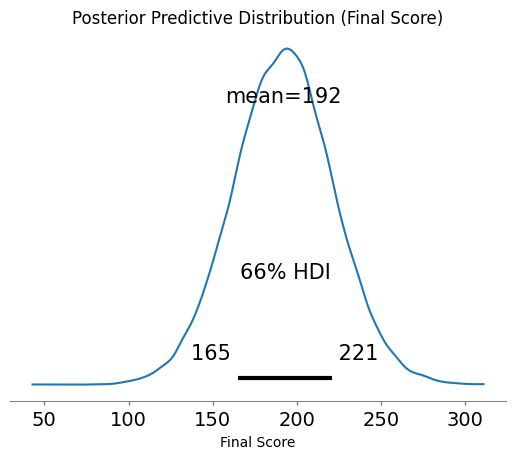

In [19]:
az.plot_posterior(
    pred_values,
    hdi_prob=0.66
)

plt.title("Posterior Predictive Distribution (Final Score)")
plt.xlabel("Final Score")
plt.show()

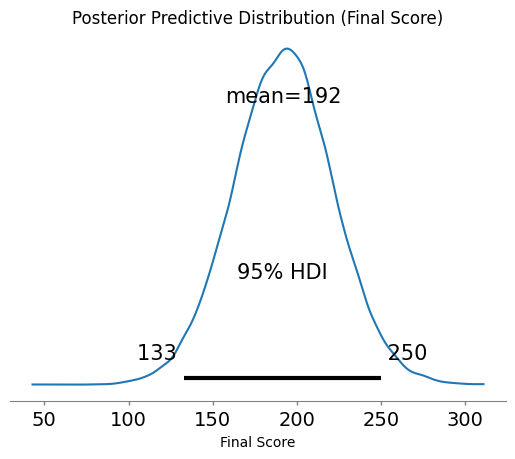

In [20]:
az.plot_posterior(
    pred_values,
    hdi_prob=0.95
)

plt.title("Posterior Predictive Distribution (Final Score)")
plt.xlabel("Final Score")
plt.show()

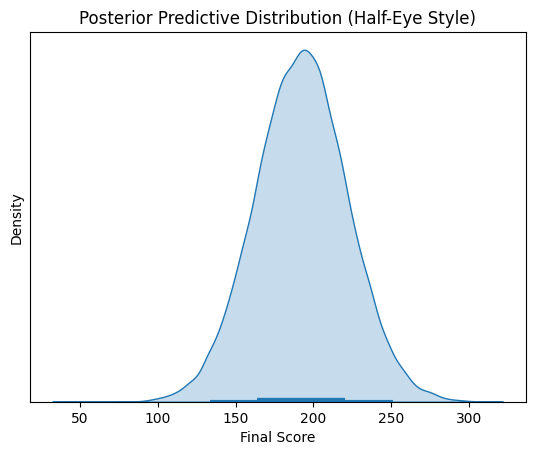

In [21]:
import seaborn as sns

# density
sns.kdeplot(pred_values, fill=True)

# intervals
low66, high66 = np.quantile(pred_values, [0.17, 0.83])
low95, high95 = np.quantile(pred_values, [0.025, 0.975])

# draw intervals
plt.hlines(y=0, xmin=low95, xmax=high95, linewidth=3)
plt.hlines(y=0, xmin=low66, xmax=high66, linewidth=6)

plt.title("Posterior Predictive Distribution (Half-Eye Style)")
plt.xlabel("Final Score")
plt.yticks([])
plt.show()

In [22]:
simple_model = bmb.Model(
    formula="Final ~ Yr2",
    data=ugtests_bayes,
    family="gaussian"
)

simple_results = simple_model.fit(
    draws=10000,
    chains=4,
    random_seed=123
)

Output()

In [23]:
## Model Comparisons ###

In [24]:
import bambi as bmb
import arviz as az

In [25]:
### Apply using log likelihood ###

In [26]:
uninf_model = bmb.Model(
    "Final ~ Yr1 + Yr2 + Yr3",
    data=ugtests_bayes,
    family="gaussian"
)

inf_model = bmb.Model(
    "Final ~ Yr1 + Yr2 + Yr3",
    data=ugtests_bayes,
    family="gaussian",
    priors={"Yr1": bmb.Prior("Normal", mu=0, sigma=0.05)}
)

simple_model = bmb.Model(
    "Final ~ Yr2",
    data=ugtests_bayes,
    family="gaussian"
)

In [27]:
uninf_results = uninf_model.fit(
    draws=10000,
    chains=4,
    random_seed=123,
    idata_kwargs={"log_likelihood": True}
)

Output()

In [28]:
inf_results = inf_model.fit(
    draws=10000,
    chains=4,
    random_seed=123,
    idata_kwargs={"log_likelihood": True}
)

Output()

In [29]:
simple_results = simple_model.fit(
    draws=10000,
    chains=4,
    random_seed=123,
    idata_kwargs={"log_likelihood": True}
)

Output()

In [30]:
comparison = az.compare(
    {
        "uninf_full": uninf_results,
        "inf_full": inf_results,
        "simple": simple_results
    },
    ic="loo"
)

print(comparison)

            rank    elpd_loo     p_loo  elpd_diff        weight        se  \
inf_full       0 -481.570798  4.228981   0.000000  1.000000e+00  6.869316   
uninf_full     1 -482.343933  4.872705   0.773134  1.443290e-15  6.770953   
simple         2 -517.481393  3.194178  35.910594  0.000000e+00  8.340911   

                 dse  warning scale  
inf_full    0.000000    False   log  
uninf_full  0.329967    False   log  
simple      7.537556    False   log  


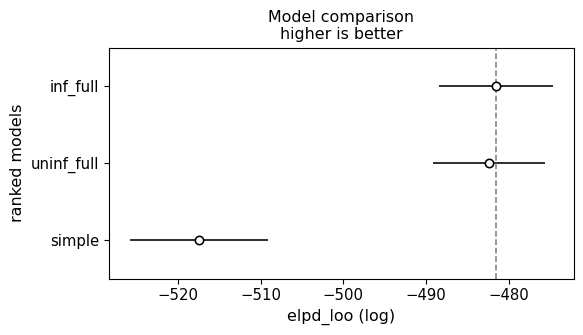

In [31]:
az.plot_compare(comparison);

In [32]:
# standardize all variables
ugtests_bayes_std = (ugtests_bayes - ugtests_bayes.mean()) / ugtests_bayes.std()

In [33]:
inf_model_std = bmb.Model(
    "Final ~ Yr1 + Yr2 + Yr3",
    data=ugtests_bayes_std,
    family="gaussian",
    priors={"Yr1": bmb.Prior("Normal", mu=0, sigma=0.05)}
)

inf_results_std = inf_model_std.fit(
    draws=10000,
    chains=4,
    random_seed=123
)

Output()

array([<Axes: title={'center': 'Yr1'}>, <Axes: title={'center': 'Yr2'}>,
       <Axes: title={'center': 'Yr3'}>], dtype=object)

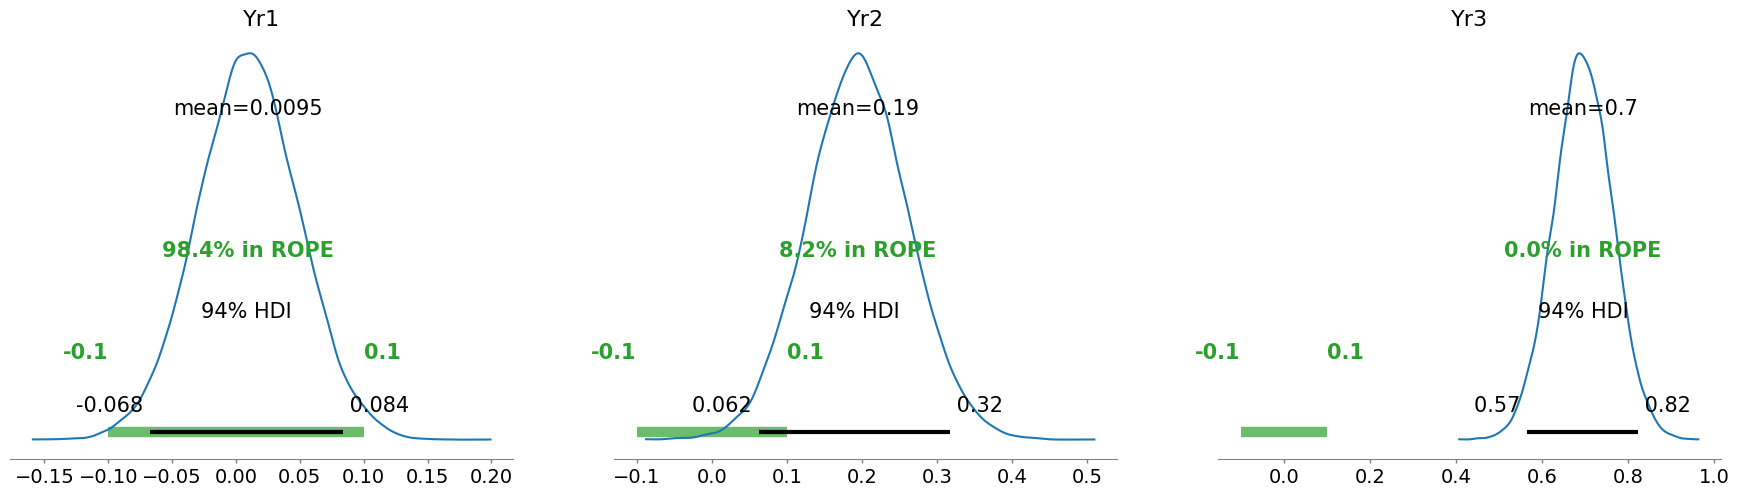

In [34]:
import arviz as az

az.plot_posterior(
    inf_results_std,
    var_names=["Yr1", "Yr2", "Yr3"],
    rope=(-0.1, 0.1)
)

In [35]:
# add posterior predictive draws to the inference object
inf_model.predict(
    inf_results,
    kind="response",
    inplace=True
)

<Axes: xlabel='Final'>

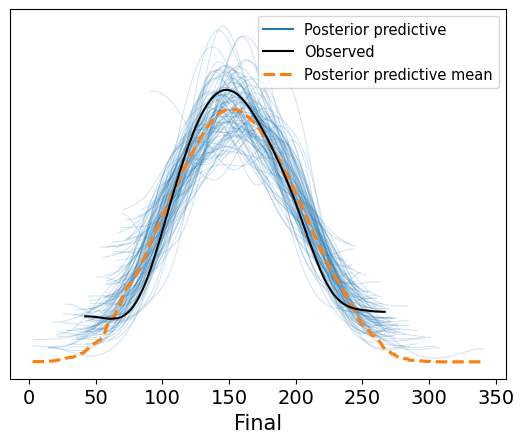

In [36]:
import arviz as az

az.plot_ppc(inf_results, num_pp_samples=100)

array([[<Axes: title={'center': 'Yr1'}>, <Axes: title={'center': 'Yr1'}>],
       [<Axes: title={'center': 'Yr2'}>, <Axes: title={'center': 'Yr2'}>],
       [<Axes: title={'center': 'Yr3'}>, <Axes: title={'center': 'Yr3'}>]],
      dtype=object)

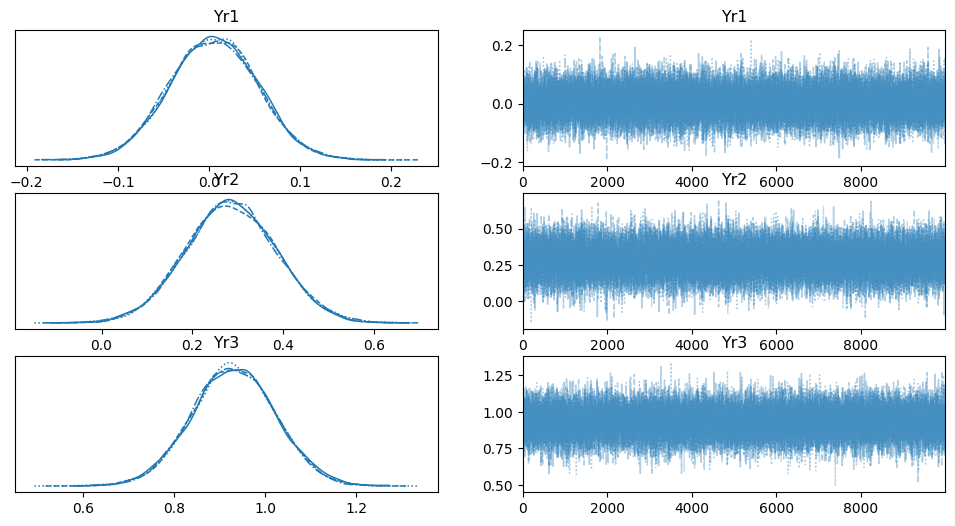

In [37]:
az.plot_trace(inf_results, var_names=["Yr1", "Yr2", "Yr3"])

In [37]:
# data exercises

In [38]:
url = "https://raw.githubusercontent.com/keithmcnulty/peopleanalytics-regression-book/master/data/sociological_data.csv"
socio = pd.read_csv(url)

In [39]:
socio.head()
socio.info()
socio.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2618 entries, 0 to 2617
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   annual_income_ppp  2608 non-null   float64
 1   average_wk_hrs     2584 non-null   float64
 2   education_months   2599 non-null   float64
 3   region             2618 non-null   object 
 4   job_type           2618 non-null   object 
 5   gender             2595 non-null   object 
 6   family_size        2427 non-null   float64
 7   work_distance      2206 non-null   float64
 8   languages          2206 non-null   float64
dtypes: float64(6), object(3)
memory usage: 184.2+ KB


,annual_income_ppp,average_wk_hrs,education_months,family_size,work_distance,languages
count,2608.000000,2584.000000,2599.000000,2427.000000,2206.000000,2206.000000
mean,76040.057132,44.190402,179.317815,3.259580,0.985041,1.018132
std,20981.738753,5.856006,39.693201,1.470578,5.020615,0.205673
min,2863.000000,30.000000,40.000000,0.000000,0.000000,1.000000
25%,62653.000000,39.000000,157.000000,2.000000,0.000000,1.000000
50%,82140.000000,43.000000,184.000000,3.000000,0.000000,1.000000
75%,90112.000000,50.000000,207.000000,4.000000,1.000000,1.000000
max,119564.000000,55.000000,280.000000,10.000000,105.000000,5.000000
